In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


2026-03-14 08:37:23.879723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773477444.087438      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773477444.155552      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**Load & Prepare Data**

In [2]:
data_dir = '/kaggle/input/brain-tumor-detection'
groups = ['yes', 'no']
file_paths = []
labels = []

for group in groups:
    fold_path = os.path.join(data_dir, group) 
    files = os.listdir(fold_path)
    for file in files:
        file_path = os.path.join(fold_path, file)
        file_paths.append(file_path)
        labels.append(group)


In [3]:
df=pd.DataFrame({'file_paths':file_paths,
                'labels':labels})

print(df.sample(10))

print(df['labels'].value_counts())


                                             file_paths labels
2477   /kaggle/input/brain-tumor-detection/no/no197.jpg     no
875    /kaggle/input/brain-tumor-detection/yes/y965.jpg    yes
1732   /kaggle/input/brain-tumor-detection/no/no553.jpg     no
1400   /kaggle/input/brain-tumor-detection/yes/y324.jpg    yes
673   /kaggle/input/brain-tumor-detection/yes/y1230.jpg    yes
1630  /kaggle/input/brain-tumor-detection/no/no1153.jpg     no
402   /kaggle/input/brain-tumor-detection/yes/y1456.jpg    yes
2186  /kaggle/input/brain-tumor-detection/no/no1223.jpg     no
723    /kaggle/input/brain-tumor-detection/yes/y983.jpg    yes
641     /kaggle/input/brain-tumor-detection/yes/y14.jpg    yes
labels
yes    1500
no     1500
Name: count, dtype: int64


**Train/Test Split**

In [4]:
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df['labels'])

**Image Data Generator**

In [5]:
gen=ImageDataGenerator()
train_gen=gen.flow_from_dataframe(train_df, x_col='file_paths', y_col='labels', 
                                    target_size=(224, 224), color_mode='grayscale', 
                                    class_mode='binary', batch_size=16)

test_gen=gen.flow_from_dataframe(test_df, x_col='file_paths', y_col='labels', 
                                    target_size=(224, 224), color_mode='grayscale', 
                                    class_mode='binary', batch_size=16)


Found 2400 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.


**Build and Compile CNN Model**

In [6]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773477460.455842      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


**Training**

In [7]:
traning = model.fit(train_gen, epochs=35, validation_data=test_gen)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35


I0000 00:00:1773477465.238856      61 service.cc:148] XLA service 0x7de2cc002de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773477465.239649      61 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773477465.662566      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/150 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.3681 - loss: 210.8439

I0000 00:00:1773477469.997458      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.6703 - loss: 28.1443 - val_accuracy: 0.7550 - val_loss: 0.5794
Epoch 2/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7511 - loss: 0.5117 - val_accuracy: 0.8100 - val_loss: 0.4512
Epoch 3/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7926 - loss: 0.4346 - val_accuracy: 0.8217 - val_loss: 0.4167
Epoch 4/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8228 - loss: 0.3981 - val_accuracy: 0.8783 - val_loss: 0.3297
Epoch 5/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8450 - loss: 0.3411 - val_accuracy: 0.8667 - val_loss: 0.3082
Epoch 6/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8736 - loss: 0.2950 - val_accuracy: 0.9133 - val_loss: 0.2448
Epoch 7/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8910 - loss: 0.2534 - val_accuracy: 0.9283 - val_loss: 0.2208
Epoch 8/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8970 - loss: 0.2523 - val_accuracy: 0.

In [8]:
model.evaluate(train_gen)

150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9985 - loss: 0.0034


[0.004089191555976868, 0.9987499713897705]

In [9]:
model.evaluate(test_gen)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9744 - loss: 0.1152


[0.0927085280418396, 0.9800000190734863]

**Performance Visualization**

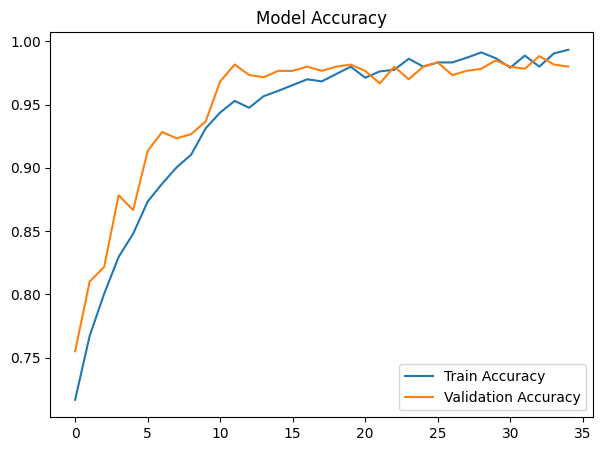

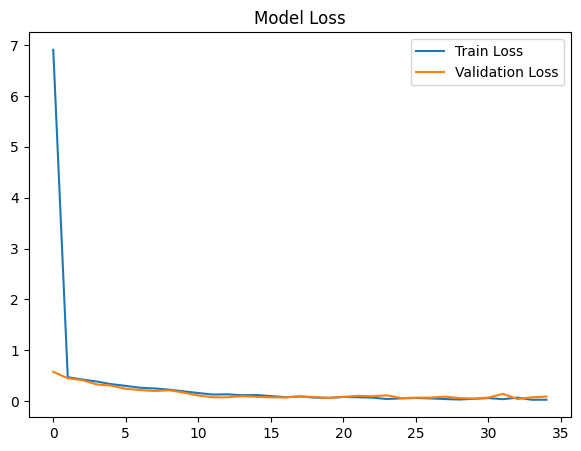

In [10]:
plt.figure(figsize=(7,5))
plt.plot(traning.history['accuracy'], label='Train Accuracy')
plt.plot(traning.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.figure(figsize=(7,5))
plt.plot(traning.history['loss'], label='Train Loss')
plt.plot(traning.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


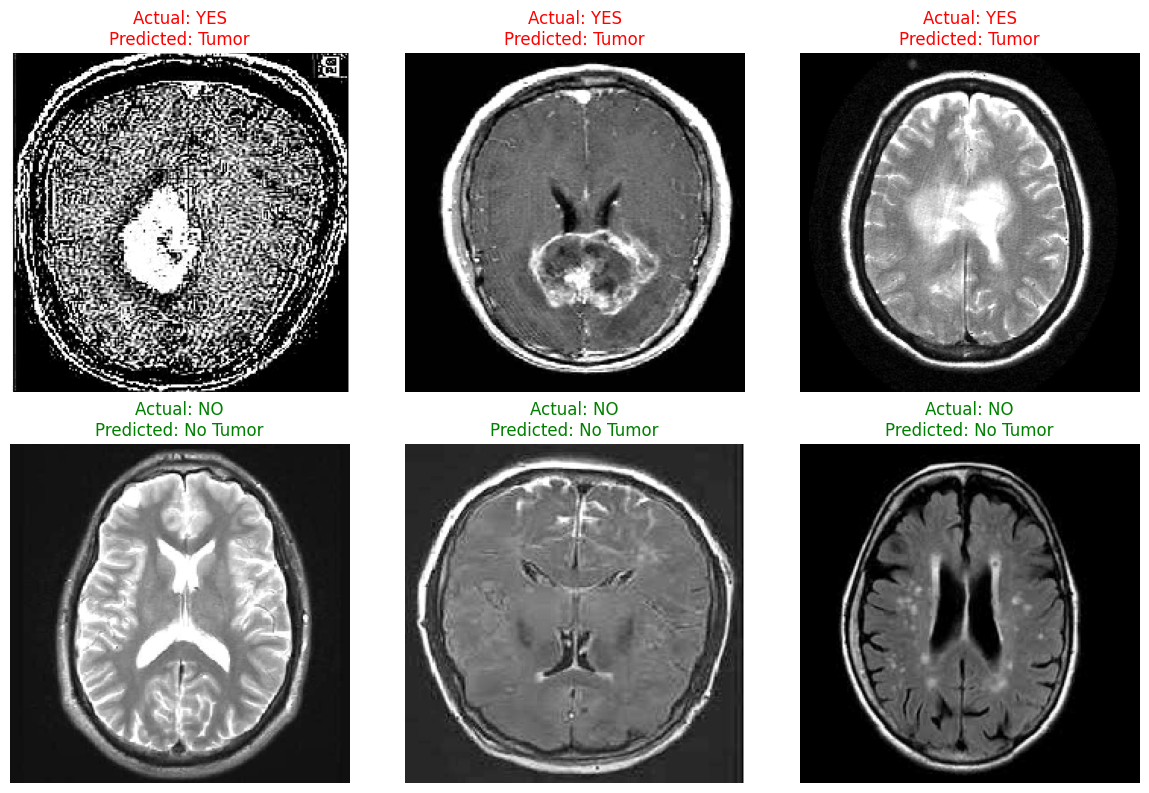

In [11]:
import random
from tensorflow.keras.preprocessing import image

def show_prediction(folder, filename):
    img_path = os.path.join(data_dir, folder, filename)
    img = image.load_img(img_path, target_size=(224,224), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 
    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        result = "Tumor"
        color = "red"
    else:
        result = "No Tumor"
        color = "green"

    plt.imshow(np.array(img).squeeze(), cmap='gray')
    plt.title(f"Actual: {folder.upper()}\nPredicted: {result}", color=color)
    plt.axis('off')


yes_images = random.sample(os.listdir(os.path.join(data_dir, 'yes')), 3)
no_images  = random.sample(os.listdir(os.path.join(data_dir, 'no')), 3)


plt.figure(figsize=(12, 8))

for i, img_name in enumerate(yes_images):
    plt.subplot(2, 3, i + 1)
    show_prediction('yes', img_name)

for i, img_name in enumerate(no_images):
    plt.subplot(2, 3, i + 4)
    show_prediction('no', img_name)

plt.tight_layout()
plt.show()

**Save Model**

In [12]:
model.save("brain_tumor_model.h5")